In [1]:
%pip install scikit-learn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Loading dataset...")
df = pd.read_csv(r"/Users/suhaas/Downloads/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df

Note: you may need to restart the kernel to use updated packages.
Loading dataset...


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [3]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [4]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [5]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


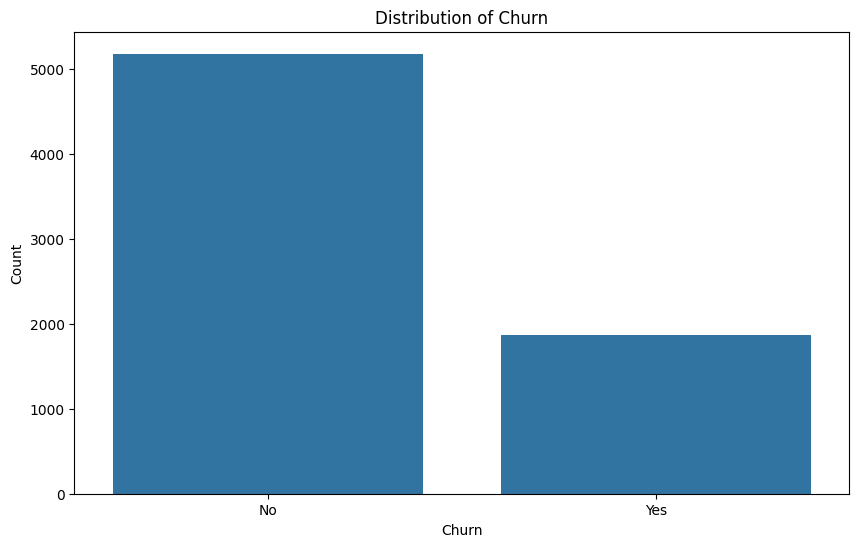

In [7]:
plt.figure(figsize=(10, 6))
sns.countplot(x="Churn", data=df)
plt.title("Distribution of Churn")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

In [8]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [9]:
print("Churn Rate = {:.2f}%".format(df["Churn"].value_counts(normalize=True)["Yes"] * 100))
print("Missing values will be filled after train test split to avoid data leakage.[filling missing values now will alter the test data also]")
print("Dataset loaded successfully!")

Churn Rate = 26.54%
Missing values will be filled after train test split to avoid data leakage.[filling missing values now will alter the test data also]
Dataset loaded successfully!


In [10]:
y = df["Churn"].map({"Yes": 1, "No": 0})
print("We change the target variable to binary for calculation of risk factor at the end to decide whether to retain the customer or not")
X=df.drop("Churn", axis=1)

We change the target variable to binary for calculation of risk factor at the end to decide whether to retain the customer or not


In [11]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [13]:
from sklearn.preprocessing import OneHotEncoder

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [14]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [15]:
from sklearn.linear_model import LogisticRegression
model_log = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000, penalty="l2", solver="lbfgs", C=0.1
    ))
])

In [16]:
from sklearn.ensemble import RandomForestClassifier
model_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100, max_depth=10, random_state=42
    ))
])

In [17]:
%pip install xgboost
%pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [18]:
from xgboost import XGBClassifier
model_xgb = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42
    ))
])

XGBoostError: 
XGBoost Library (libxgboost.dylib) could not be loaded.
Likely causes:
  * OpenMP runtime is not installed
    - vcomp140.dll or libgomp-1.dll for Windows
    - libomp.dylib for Mac OSX
    - libgomp.so for Linux and other UNIX-like OSes
    Mac OSX users: Run `brew install libomp` to install OpenMP runtime.

  * You are running 32-bit Python on a 64-bit OS

Error message(s): ["dlopen(/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/xgboost/lib/libxgboost.dylib, 0x0006): Library not loaded: @rpath/libomp.dylib\n  Referenced from: <1A0D8152-BF46-3BE0-B651-EE965C187777> /Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/xgboost/lib/libxgboost.dylib\n  Reason: tried: '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/O

In [ ]:
print("We use simple imputer and not fillna method becoz when we use fillna method the median or mode iscalculated for ")
print("train test aseparately and applies to that set only but when we use simple imputer the median or mode is calculated for")
print("train set and applied to both train and test set which is the correct way to do it to avoid data leakage else we might not get the same level of " )
print("accuracy as we get on the test set when we deploy the model in production.")

We use simple imputer and not fillna method becoz when we use fillna method the median or mode iscalculated for 
train test aseparately and applies to that set only but when we use simple imputer the median or mode is calculated for
train set and applied to both train and test set which is the correct way to do it to avoid data leakage else we might not get the same level of 
accuracy as we get on the test set when we deploy the model in production.


In [ ]:
print("fit is learning the parameters of the pipeline and transform is applying those parameters to the data")

fit is learning the parameters of the pipeline and transform is applying those parameters to the data


In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report
import numpy as np

In [ ]:
skf = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

In [ ]:
fold_results = []
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
#train and val idx return the index of rows in training and testing dataset respectively for each fold
#this is for logistic regression model
    print(f"\nFold: {fold}")

    X_train_fold = X.iloc[train_idx]
    y_train_fold = y.iloc[train_idx]

    X_val_fold = X.iloc[val_idx]
    y_val_fold = y.iloc[val_idx]

    model_log.fit(X_train_fold, y_train_fold)

    val_probs = model_log.predict_proba(X_val_fold)[:, 1]

    val_preds = (val_probs >= 0.5).astype(int)

    roc_auc = roc_auc_score(y_val_fold, val_probs)
    pr_auc = average_precision_score(y_val_fold, val_probs)

    report = classification_report(y_val_fold, val_preds, output_dict=True)

    recall = report["1"]["recall"]
    precision = report["1"]["precision"]

    fold_results.append({
        "fold": fold,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "recall": recall,
        "precision": precision
    })


Fold: 1

Fold: 2

Fold: 3

Fold: 4

Fold: 5


In [ ]:
log_results = pd.DataFrame(fold_results)

log_results

,fold,roc_auc,pr_auc,recall,precision
0,1,0.854131,0.658922,0.569519,0.669811
1,2,0.844346,0.655874,0.564171,0.667722
2,3,0.862975,0.697507,0.577540,0.694534
3,4,0.824837,0.616657,0.485255,0.619863
4,5,0.835260,0.642954,0.518717,0.640264


In [ ]:
print("\nMean Metrics")
print(cv_results.mean())

print("\nStd Deviation")
print(cv_results.std())


Mean Metrics
fold         3.000000
roc_auc      0.844310
pr_auc       0.654383
recall       0.543040
precision    0.658439
dtype: float64

Std Deviation
fold         1.581139
roc_auc      0.015049
pr_auc       0.029310
recall       0.039587
precision    0.028882
dtype: float64


In [ ]:
fold_results = []
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
#train and val idx return the index of rows in training and testing dataset respectively for each fold
#this is for random forests model
    print(f"\nFold: {fold}")

    X_train_fold = X.iloc[train_idx]
    y_train_fold = y.iloc[train_idx]

    X_val_fold = X.iloc[val_idx]
    y_val_fold = y.iloc[val_idx]

    model_rf.fit(X_train_fold, y_train_fold)

    val_probs = model_rf.predict_proba(X_val_fold)[:, 1]

    val_preds = (val_probs >= 0.5).astype(int)

    roc_auc = roc_auc_score(y_val_fold, val_probs)
    pr_auc = average_precision_score(y_val_fold, val_probs)

    report = classification_report(y_val_fold, val_preds, output_dict=True)

    recall = report["1"]["recall"]
    precision = report["1"]["precision"]

    fold_results.append({
        "fold": fold,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "recall": recall,
        "precision": precision
    })

In [ ]:
rf_results = pd.DataFrame(fold_results)

rf_results

,fold,roc_auc,pr_auc,recall,precision
0,1,0.854131,0.658922,0.569519,0.669811
1,2,0.844346,0.655874,0.564171,0.667722
2,3,0.862975,0.697507,0.577540,0.694534
3,4,0.824837,0.616657,0.485255,0.619863
4,5,0.835260,0.642954,0.518717,0.640264


In [ ]:
print("\nMean Metrics")
print(rf_results.mean())

print("\nStd Deviation")
print(rf_results.std())


Mean Metrics
fold         3.000000
roc_auc      0.844310
pr_auc       0.654383
recall       0.543040
precision    0.658439
dtype: float64

Std Deviation
fold         1.581139
roc_auc      0.015049
pr_auc       0.029310
recall       0.039587
precision    0.028882
dtype: float64


In [ ]:
#rn we have used 32 bit python which is enuf for basic ml but now for deep stuff like xgboost and production grade systems we need 64 bit python


In [ ]:
#l2 means its squares the error and adds it to the loss function to penalize the model for large coefficients and
# liblinear is a solver that is used for small datasets and it is a good choice for binary classification problems.
# lbfgs is a solver that is used for large datasets and it is a good choice for multiclass classification problems.
# C controls the regularization strength and it is a hyperparameter that we can tune to get better performance from the model.
# (higher the value of c less regularization)

In [ ]:

print("Model trained successfully!")
#convergence is saturation point where how much i ever i change my wieghts further the performance will not improve
#max_iter is hthe number of chances to adjust the weights to reach the convergence point and if we dont reach the convergence point 
# in those chances we get a warning that the model did not converge and we might not get the best performance from the model.

Model trained successfully!


In [ ]:
#predict_proba gives the probability of the positive class and we take the second column of the output to get the probabilities of the positive class.
#roc_auc_score is a metric that is used to evaluate the performance of a binary classification model and it is calculated as the area under the
#  receiver operating characteristic curve (ROC curve) and it ranges from 0 to 1 and higher the value better the performance of the model.
#it maps true positive rate and false positive rate at different threshold values and gives us an idea of how well the model is able to distinguish between the positive and negative classes.

In [ ]:
#lbfgs and liblinear almost gave same roc auc score.(lbfgs is faster and a bit better)

In [ ]:
#the main idea of this project is to find out which customers are likely to churn and then target those customers.
#if the benefit of retaining the customer is more than the cost of retention then we will retain the customer else let em go
#rn our threshold is 0.5 default so we reduce it 0.2 to reatin more customers and see if we get better performance from the model.
#we are basically being extra careful to retain the customers and we are ok with some false positives 
# as long as we are able to retain more customers and get better performance from the model.

In [ ]:
#[tn fp]
#[fn tp]

In [ ]:
#after predicting if the customer is churing or now ... now we need to decide which is more beneificial...
# 1. retaining a customer
# 2. losing a customer
#this we decide based upon the benefit the customer brings which is equal to the potential 
# revenue from the customer minus the cost of retention

# we will assume the cost of retention is 500(call center, discounts, coupons, pamplets etc)
# to calculate the potential revenue... we multiply the monthly charges and time

# we assume that the customer will stay for the next 12 months if we retain them and then we 
# can calculate the potential revenue as monthly charges * 12 - cost of retention 
# and if this value is positive then we will retain the customer else we will let em go.


In [ ]:
results = X_test.copy()
results["actual_churn"] = y_test.values
results["churn_prob"] = model.predict_proba(X_test)[:, 1]

results["LTV"] = results["MonthlyCharges"] * 12
#here we are creating a table results same as x_test and adding cols of acutal churn and churn probability
#then use those for calculating te lifetime value of the customer


In [ ]:
results.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,actual_churn,churn_prob,LTV
437,4376-KFVRS,Male,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Two year,Yes,Credit card (automatic),114.05,8468.20,0,0.041002,1368.6
2280,2754-SDJRD,Female,1,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,Yes,Month-to-month,Yes,Credit card (automatic),100.15,908.55,0,0.689232,1201.8
2235,9917-KWRBE,Female,0,Yes,Yes,41,Yes,Yes,DSL,Yes,...,Yes,No,One year,Yes,Credit card (automatic),78.35,3211.20,0,0.066505,940.2
4460,0365-GXEZS,Male,0,Yes,No,18,Yes,No,Fiber optic,No,...,No,No,Month-to-month,No,Electronic check,78.20,1468.75,0,0.391958,938.4
3761,9385-NXKDA,Female,0,Yes,No,72,Yes,Yes,DSL,Yes,...,Yes,Yes,Two year,Yes,Credit card (automatic),82.65,5919.35,0,0.024580,991.8


In [ ]:
#first we need to fix the right threshold value giving max profit by calculating Life time value / cost....if its greater than 1 then we will retain the customer else we will let em go.
#so to find the right threshold we do optimization

In [ ]:
import numpy as np
thresholds = np.linspace(0.05, 0.8, 50)
profits = []
for threshold in thresholds:
    decision = (results["churn_prob"] >= threshold).astype(int)
    profit = ((decision) & (results["actual_churn"] == 1)) * (results["LTV"] - 500)
#if we retain a churning chustomer then the profit we saved is above and we add it to the profit
    profit -= ((decision) & (results["actual_churn"] == 0)) * 500
# if we retain a non churning customer then the cost we incur is above and we subtract it from the profit
    profit -= ((~decision) & (results["actual_churn"] == 1)) * results["LTV"]
# if we did not retain a churning customer then the loss we incur is above and we subtract it from the profit
#and someone who isnt churning we dont care about them
    profits.append(profit.sum())
best_threshold = thresholds[np.argmax(profits)]
print("Best Threshold: {:.2f}".format(best_threshold))

Best Threshold: 0.28


In [ ]:
y_pred = (y_probs >= best_threshold).astype(int)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(roc_auc_score(y_test, y_probs))

[[766 269]
 [ 84 290]]
              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1035
           1       0.52      0.78      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409

0.8409155493554471


In [ ]:
#thus we optimized our threshold value to get the best profit and we are able to retain more customers and get better performance from the model.
#now we arrange our customers in terms of highest risk factor and target those customers first for retention.
results["expected_loss"] = results["churn_prob"] * results["LTV"]

In [ ]:
ranked_customers = results.sort_values(
    by="expected_loss",
    ascending=False
)
ranked_customers["rank"] = range(1, len(ranked_customers) + 1)

In [ ]:
ranked_customers
#Model outputs churn probabilities.
#We compute expected loss = P(churn) × LTV.
#We intervene if expected benefit exceeds retention cost.
#This leads to optimal threshold = Cost / LTV.
#Alternatively, if budget is constrained, we rank by expected loss and target top N customers.

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,actual_churn,churn_prob,LTV,expected_loss,rank
6894,1400-MMYXY,Male,1,Yes,No,3,Yes,Yes,Fiber optic,No,...,Month-to-month,Yes,Electronic check,105.90,334.65,1,0.825683,1270.8,1049.278156,1
6365,8884-ADFVN,Male,1,Yes,No,7,Yes,Yes,Fiber optic,No,...,Month-to-month,Yes,Electronic check,101.95,700.85,1,0.831756,1223.4,1017.569726,2
2797,6023-YEBUP,Male,0,No,No,3,Yes,Yes,Fiber optic,No,...,Month-to-month,Yes,Electronic check,100.95,329.95,1,0.825109,1211.4,999.536455,3
3956,4587-VVTOX,Female,0,Yes,No,6,Yes,Yes,Fiber optic,No,...,Month-to-month,Yes,Electronic check,105.30,545.20,1,0.782503,1263.6,988.770511,4
2631,6861-XWTWQ,Male,1,Yes,No,7,Yes,Yes,Fiber optic,No,...,Month-to-month,Yes,Electronic check,99.25,665.45,1,0.829475,1191.0,987.905023,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1824,0794-YVSGE,Male,0,Yes,Yes,72,Yes,No,No,No internet service,...,Two year,No,Bank transfer (automatic),20.30,1401.15,0,0.003299,243.6,0.803643,1405
3375,3642-BYHDO,Female,0,Yes,Yes,71,Yes,No,No,No internet service,...,Two year,No,Bank transfer (automatic),19.90,1389.35,0,0.003351,238.8,0.800301,1406
2338,4277-BWBML,Male,0,Yes,Yes,72,Yes,No,No,No internet service,...,Two year,No,Bank transfer (automatic),19.95,1322.85,0,0.003268,239.4,0.782255,1407
6614,4086-WITJG,Male,0,Yes,Yes,71,Yes,No,No,No internet service,...,Two year,No,Credit card (automatic),19.70,1301.10,0,0.003287,236.4,0.776940,1408


In [ ]:
#SO WE SUCCESSFULLY BUILD A MODEL WHICH WILL SEE THRU UR CUSTOMER LISTS AND TELL U WHO IS ABOUT TO CHURN AND HOW MUCH DO THEY AFFECT TO UR COMPANY 
# AND THEN U CAN TARGET THOSE CUSTOMERS FIRST FOR RETENTION

In [ ]:
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
coefs = model.named_steps["classifier"].coef_[0]

import pandas as pd

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefs
})

coef_df["abs_coef"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values(by="abs_coef", ascending=False)

coef_df.head(20)

,feature,coefficient,abs_coef
1,num__tenure,-0.977126,0.977126
5670,cat__Contract_Month-to-month,0.633567,0.633567
5672,cat__Contract_Two year,-0.579514,0.579514
5650,cat__InternetService_Fiber optic,0.393317,0.393317
5649,cat__InternetService_DSL,-0.319345,0.319345
5677,cat__PaymentMethod_Electronic check,0.274295,0.274295
5652,cat__OnlineSecurity_No,0.255678,0.255678
3,num__TotalCharges,0.232153,0.232153
5661,cat__TechSupport_No,0.229033,0.229033
5646,cat__MultipleLines_No,-0.194223,0.194223


In [ ]:
#so we know which features are most important
#larger the absolute value of the coefficient more important the feature is for predicting churn.
#pos coefficients means increasing the feature increases the probability of churn and neg coefficients means increasing the feature decreases the probability of churn.
#we are able to compare based on abs value only becauase we have scaled the numeric features and one hot encoded the categorical features so they are on the same scale
#so we can compare the coefficients directly.

In [ ]:
#till now we have done trai-test split to the data...now to ensure our model gives stable performance we can do cross validation 
# and see if we get similar performance on different folds of the data and then we can be more confident about our model's performance in production.
#we will do 5 fold cross validation and see the roc auc score for each fold and then we will take the average of those scores to get the final roc auc score for the model.
#5 folds mean we will split the data into 5 parts and then we will train the model on 4 parts and test on the remaining part and 
# we will do this 5 times and then we will take the average of the roc auc scores to get the final roc auc score for the model.